In [14]:
from tsg import LinearTrendGenerator
from tsg.modifiers import GaussianNoise
from custom_agents import SGDAllocAgent
from custom_generators import NoiseTrajectoryWrapper
from factories import make_task_factory
from ct3 import CT3Runner
from tsdm.tasks import AllocationTask
from metrics import metric_allocation

In [15]:
# Instantiate generators

gen_lin = LinearTrendGenerator(slope=0.1)
gen_lin_noise = GaussianNoise(gen_lin,mu=0,sigma=0.5)

gen_const = LinearTrendGenerator(slope=0)
gen_const_noise = GaussianNoise(gen_const,mu=0,sigma=0.5)

In [16]:

agent = SGDAllocAgent(n_assets=2)


In [17]:
task = AllocationTask(generators=[gen_const_noise, gen_lin_noise],
                      agent=agent,
                      total_movements=10000,
                      initial_budget=1,
                      tc= 0.0)

reward = task.play_game()
print(f"Reward during training: {reward}")

Reward during training: 4.026730281045146e-50


In [18]:
task.log

[{'t': 1,
  'values': array([10.18196028,  9.80703476]),
  'relative_changes': array([0., 0.]),
  'allocations': array([0.5, 0.5]),
  'turnover': 0.0,
  'combined_change': 0.0,
  'new_budget': 1.0},
 {'t': 2,
  'values': array([10.36036946, 10.67375004]),
  'relative_changes': array([0.01752209, 0.08837689]),
  'allocations': array([9.99954602e-01, 4.53978687e-05]),
  'turnover': 0.9999092042625952,
  'combined_change': 0.01752530244491084,
  'new_budget': 1.017525302444911},
 {'t': 3,
  'values': array([10.13277413, 10.30806822]),
  'relative_changes': array([-0.02196788, -0.03425992]),
  'allocations': array([3.12866049e-07, 9.99999687e-01]),
  'turnover': 1.9999085785304975,
  'combined_change': -0.03425991608014086,
  'new_budget': 0.9826649709737283},
 {'t': 4,
  'values': array([10.97945103, 10.51537108]),
  'relative_changes': array([0.08355825, 0.02011074]),
  'allocations': array([9.99953806e-01, 4.61939565e-05]),
  'turnover': 1.9999069863549133,
  'combined_change': 0.083555

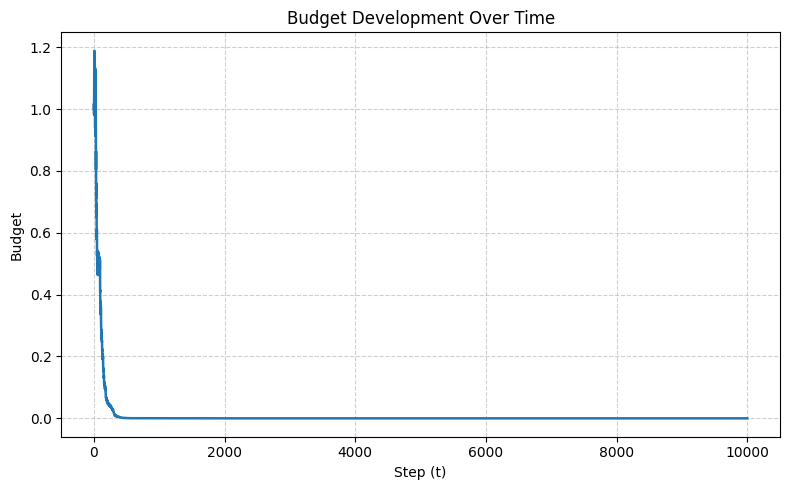

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Suppose 'log' is your task.log (list of dicts as shown)
log = task.log  # or the slice you posted above

# Extract step index and budget
t = np.array([rec["t"] for rec in log])
budget = np.array([rec["new_budget"] for rec in log])

plt.figure(figsize=(8, 5))
plt.plot(t, budget, lw=1.8, color="tab:blue")
plt.xlabel("Step (t)")
plt.ylabel("Budget")
plt.title("Budget Development Over Time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [20]:
# ---- freeze the trained policy for evaluation ----
agent.freeze()
agent.soft_reset()  # clear buffers before eval

In [21]:
# =========================
# AllocationTask CT3 setup with LinearTrend(+noise)
# - Gen1: "constant" via LinearTrendGenerator(mu=0.0)
# - Gen2: LinearTrendGenerator(mu=μ)
# =========================

# Assumes these exist:
#   - AllocationTask
#   - LinearTrendGenerator(mu)
#   - NoiseTrajectoryWrapper(base_generator, eps[, ...])
#   - make_task_factory(...) from your earlier code
#   - alloc_agent: an allocation-capable agent (e.g., SGDAllocAgent)

# 1) Build task factory (two generators)
build_all_alloc = make_task_factory(
    task_cls=AllocationTask,
    gen_factory=[
        lambda mu: LinearTrendGenerator(slope=0.0),  # constant leg
        lambda mu: LinearTrendGenerator(slope=mu),   # μ-varying trend leg
    ],
    agent=agent,
    noise_wrapper_cls=NoiseTrajectoryWrapper,
    total_movements=1000,
    start_values=[10.0, 10.0],   # one start value per generator
    tc=0.0,                  # optional turnover cost
)

# 2) Build CT3-style bundles
bundle_alloc = build_all_alloc(
    param_grid=[-0.5, -0.25, 0.0, 0.25, 0.5],  # μ values to test on the trend leg
    reference_param=0.25,                       # baseline: both legs flat (trend μ=0)
    task_horizon=1000,
    n_noise_paths=8,
    seed=123,
)

# bundle_alloc structure:
# {
#   "eps_paths": [array, ...],
#   "reference": [AllocationTask, ...],     # μ_ref = 0.0
#   "by_mu": { μ: [AllocationTask, ...], ...}
# }

# 3) (Optional) Run one reference task and one μ example
ref_task = bundle_alloc["reference"][0]
final_budget_ref = ref_task.play_game()
print(f"Reference μ=0.25 final budget: {final_budget_ref:.6f}")

mu_example = -0.25
task_mu0 = bundle_alloc["by_mu"][mu_example][0]
final_budget_mu = task_mu0.play_game()
print(f"μ={mu_example:+.2f} final budget: {final_budget_mu:.6f}")



Reference μ=0.25 final budget: 66.274379
μ=-0.25 final budget: 0.000000


In [22]:
# 2) Create CT3 runner and run
ct3 = CT3Runner(
    build_all=build_all_alloc,
    param_grid=[-0.5, -0.25, 0.0, 0.25, 0.5],
    reference_param=0.0,
    task_horizon=1000,
    n_noise_paths=8,
    seed=123,
    metrics=[metric_allocation(warmup=getattr(agent, "window_size", 0))],
)

raw = ct3.run()
agg = ct3.agg 

# 3) (Optional) Plot your response using your existing plotter by reading ct3.agg
print(agg)

{-0.5: {'alloc_L1': {'mean': 0.8431842357372568, 'ci95': (0.8414851082590331, 0.8448833632154804)}, 'alloc_response': {'mean': -0.4215880958404682, 'ci95': (-0.4224377459007061, -0.4207384457802303)}}, -0.25: {'alloc_L1': {'mean': 1.1091702901287714, 'ci95': (1.1079125123635352, 1.1104280678940077)}, 'alloc_response': {'mean': -0.5545772189752973, 'ci95': (-0.5552061127359541, -0.5539483252146405)}}, 0.0: {'alloc_L1': {'mean': 0.0, 'ci95': (0.0, 0.0)}, 'alloc_response': {'mean': 0.0, 'ci95': (0.0, 0.0)}}, 0.25: {'alloc_L1': {'mean': 0.13001666247056703, 'ci95': (0.1298146167726573, 0.13021870816847678)}, 'alloc_response': {'mean': -0.06500833123528352, 'ci95': (-0.06510935408423839, -0.06490730838632865)}}, 0.5: {'alloc_L1': {'mean': 0.2026784617783573, 'ci95': (0.2025221639373456, 0.202834759619369)}, 'alloc_response': {'mean': -0.10133923088917865, 'ci95': (-0.1014173798096845, -0.1012610819686728)}}}


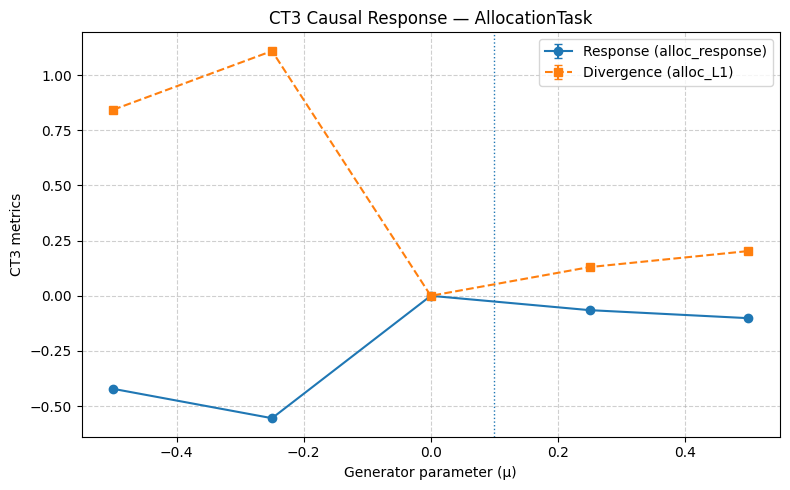

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# assume 'agg' is your CT3Runner.agg dict
mus = sorted(agg.keys())

def get_series(key):
    m, lo, hi = [], [], []
    for mu in mus:
        e = agg[mu].get(key)
        if e is None:
            m.append(np.nan); lo.append(np.nan); hi.append(np.nan)
        else:
            m.append(e["mean"]); lo.append(e["ci95"][0]); hi.append(e["ci95"][1])
    return np.array(m), np.array(lo), np.array(hi)

# --- NEW metrics ---
div_m, div_lo, div_hi   = get_series("alloc_L1")         # divergence
resp_m, resp_lo, resp_hi = get_series("alloc_response")  # response (signed, mechanism-aligned)

# (optional) keep performance for context
try:
    perf_m, perf_lo, perf_hi = get_series("Δfinal_budget")
    have_perf = np.isfinite(perf_m).any()
except Exception:
    have_perf = False

fig, ax = plt.subplots(figsize=(8, 5))

# Response (mechanism-aligned)
ax.errorbar(
    mus, resp_m,
    yerr=[resp_m - resp_lo, resp_hi - resp_m],
    fmt="o-", capsize=3, label="Response (alloc_response)"
)

# Divergence (policy distance)
ax.errorbar(
    mus, div_m,
    yerr=[div_m - div_lo, div_hi - div_m],
    fmt="s--", capsize=3, label="Divergence (alloc_L1)"
)

# Optional performance curve
if have_perf:
    ax.errorbar(
        mus, perf_m,
        yerr=[perf_m - perf_lo, perf_hi - perf_m],
        fmt="^:", capsize=3, label="Δ Final Budget"
    )

ax.axvline(0.1, linestyle=":", linewidth=1)
ax.set_xlabel("Generator parameter (μ)")
ax.set_ylabel("CT3 metrics")
ax.set_title("CT3 Causal Response — AllocationTask")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


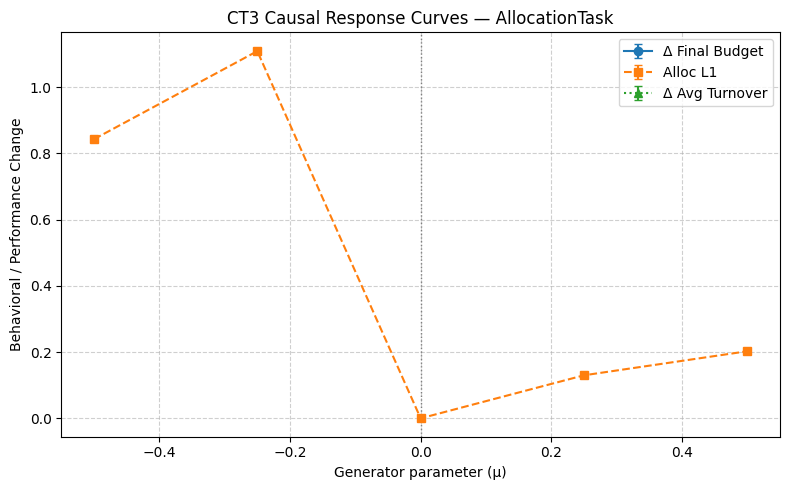

In [24]:
import matplotlib.pyplot as plt
import numpy as np



# ---- Extract sorted parameter values ----
mus = sorted(agg.keys())

def get_series(key):
    """Extract mean and confidence intervals for a metric key."""
    m, lo, hi = [], [], []
    for mu in mus:
        entry = agg[mu].get(key, None)
        if entry is None:
            m.append(np.nan); lo.append(np.nan); hi.append(np.nan)
        else:
            m.append(entry["mean"])
            lo.append(entry["ci95"][0])
            hi.append(entry["ci95"][1])
    return np.array(m), np.array(lo), np.array(hi)

# ---- Extract series ----
alloc_m, alloc_lo, alloc_hi   = get_series("alloc_L1")
turn_m, turn_lo, turn_hi      = get_series("Δavg_turnover")
budget_m, budget_lo, budget_hi = get_series("Δfinal_budget")

# ---- Create the plot ----
fig, ax1 = plt.subplots(figsize=(8, 5))

# Δfinal_budget (performance)
ax1.errorbar(
    mus, budget_m, 
    yerr=[budget_m - budget_lo, budget_hi - budget_m],
    fmt="o-", capsize=3, color="tab:blue", label="Δ Final Budget"
)

# alloc_L1 (behavioral distance)
ax1.errorbar(
    mus, alloc_m,
    yerr=[alloc_m - alloc_lo, alloc_hi - alloc_m],
    fmt="s--", capsize=3, color="tab:orange", label="Alloc L1"
)

# Δavg_turnover (effort)
ax1.errorbar(
    mus, turn_m,
    yerr=[turn_m - turn_lo, turn_hi - turn_m],
    fmt="^:", capsize=3, color="tab:green", label="Δ Avg Turnover"
)

ax1.axvline(0.0, linestyle=":", color="gray", linewidth=1)
ax1.set_xlabel("Generator parameter (μ)")
ax1.set_ylabel("Behavioral / Performance Change")
ax1.set_title("CT3 Causal Response Curves — AllocationTask")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [25]:
import pandas as pd

df = pd.DataFrame({
    "μ": mus,
    "Δ Final Budget (mean)": budget_m,
    "Δ Final Budget (CI low)": budget_lo,
    "Δ Final Budget (CI high)": budget_hi,
    "Alloc L1 (mean)": alloc_m,
    "Δ Avg Turnover (mean)": turn_m,
})

# round for nice formatting
df_rounded = df.round(4)
print("\n=== CT3 Aggregated Results Table ===")
print(df_rounded.to_string(index=False))

# --- Optional: pretty display in notebook ---
try:
    from IPython.display import display
    display(df_rounded.style.set_caption("CT3 Aggregated Results (AllocationTask)").background_gradient(cmap="Blues"))
except ImportError:
    pass


=== CT3 Aggregated Results Table ===
    μ  Δ Final Budget (mean)  Δ Final Budget (CI low)  Δ Final Budget (CI high)  Alloc L1 (mean)  Δ Avg Turnover (mean)
-0.50                    NaN                      NaN                       NaN           0.8432                    NaN
-0.25                    NaN                      NaN                       NaN           1.1092                    NaN
 0.00                    NaN                      NaN                       NaN           0.0000                    NaN
 0.25                    NaN                      NaN                       NaN           0.1300                    NaN
 0.50                    NaN                      NaN                       NaN           0.2027                    NaN


c:\Users\JanderM\AppData\Local\anaconda3\envs\ct3\Lib\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\JanderM\AppData\Local\anaconda3\envs\ct3\Lib\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,μ,Δ Final Budget (mean),Δ Final Budget (CI low),Δ Final Budget (CI high),Alloc L1 (mean),Δ Avg Turnover (mean)
0,-0.500000,nan,nan,nan,0.843200,nan
1,-0.250000,nan,nan,nan,1.109200,nan
2,0.000000,nan,nan,nan,0.000000,nan
3,0.250000,nan,nan,nan,0.130000,nan
4,0.500000,nan,nan,nan,0.202700,nan
